In [53]:
import h5py
import torch
import numpy as np
import json
import os
import matplotlib.pyplot as plt

<h4>Util Functions</h4>

In [54]:
def save_dict_hdf5(dict_to_save, file_name):
    with h5py.File(file_name, 'w') as f:
        for key, value in dict_to_save.items():
            f.create_dataset(key, data=value)

def load_dict_hdf5(file_name):
    dictionary = {}
    with h5py.File(file_name, 'r') as f:
        for key in f.keys():
            dictionary[key] = f[key][:]
    
    return dictionary

def load_config_json(path):
    with open(path, 'r') as f:
        config_file = json.load(f)
        return config_file

<h4>Load Config File</h4>

In [55]:
path_to_experiments = os.path.abspath(r"../../ImageInpaintingExperiments")
experiment_id = "Test01"
path_to_folder = os.path.join(path_to_experiments, experiment_id)

config = load_config_json(path=os.path.join(path_to_folder, "config.json"))

path_to_train_dict = os.path.join(path_to_folder, "train_data_dict.hdf5")
path_to_val_dict = os.path.join(path_to_folder, "val_data_dict.hdf5")
path_to_model = os.path.join(path_to_folder, "model.pth")

<h4>Loading Data Dicts</h4>

In [56]:
train_dict = load_dict_hdf5(path_to_train_dict)
val_dict = load_dict_hdf5(path_to_val_dict)

In [57]:
print(train_dict.keys())
print(train_dict["loss_list"].shape)
print(val_dict["loss_list"].shape)

dict_keys(['input_images', 'loss_list', 'pred_images', 'target_images'])
(23524,)
(5882,)


In [65]:
idx = 8

input_image = np.moveaxis(train_dict["input_images"][idx], 0, -1)
pred_image = np.moveaxis(train_dict["pred_images"][idx], 0, -1)
target_image = np.moveaxis(train_dict["target_images"][idx], 0, -1)
print(input_image.shape)
print(input_image.min())
print(input_image.max())

(100, 100, 3)
-2.1996918
2.47576


<h4>Plotting Sample Image</h4>

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


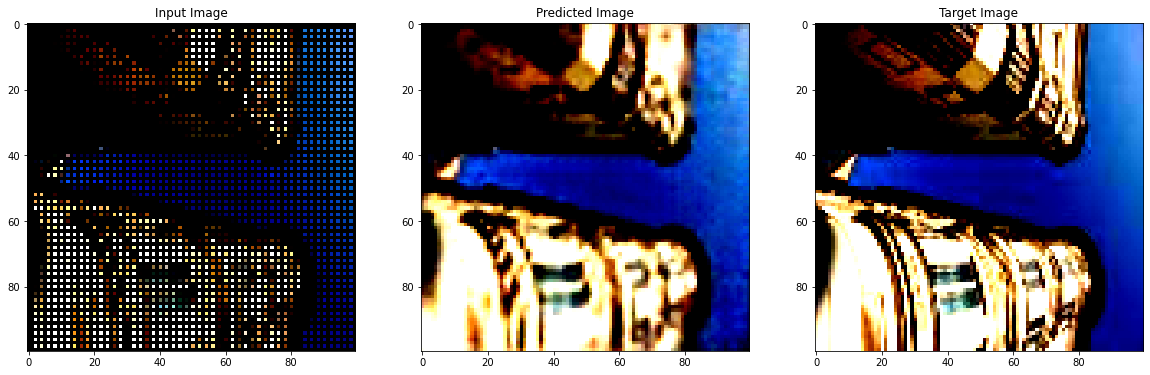

In [66]:
fig, axs = plt.subplots(1,3, figsize=(20,20))

axs[0].imshow(input_image)
axs[0].set_title("Input Image")

axs[1].imshow(pred_image)
axs[1].set_title("Predicted Image")

axs[2].imshow(target_image)
axs[2].set_title("Target Image")

plt.show()

<h4>Plotting Loss Histogram over all samples from training and validation set</h4>

Training Set:
min:  0.0006700506
median:  0.041597337
max:  0.5943687

------------------------------

Validation Set:
min:  0.0009855907
median:  0.042186335
max:  0.8532178


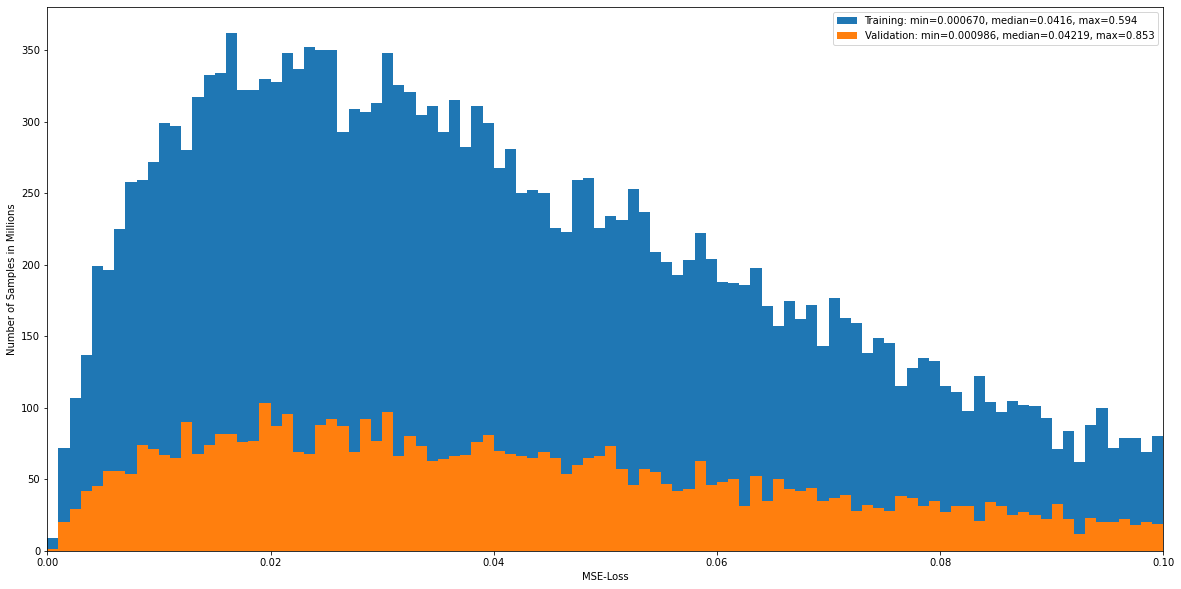

In [60]:
train_loss = train_dict["loss_list"]
val_loss = val_dict["loss_list"]

plt.figure(figsize=(20, 10))
#mini = np.min(np.sort(train_dict["CE_loss"]))
#mini_round = round(mini, 5)
#print(mini_round)
t = plt.hist(train_loss, bins=100, range=(0, 0.1), label="Training: min={:.6f}, median={:.6}, max={:.4}".format(np.min(np.sort(train_loss)), np.median(np.sort(train_loss)).round(5), np.max(np.sort(train_loss)).round(3)))
v = plt.hist(val_loss, bins=100, range=(0, 0.1), label="Validation: min={:.6f}, median={:.6}, max={:.4}".format(np.min(np.sort(val_loss)), np.median(np.sort(val_loss)).round(5), np.max(np.sort(val_loss)).round(3)))

plt.xlim([0, 0.1])
plt.xlabel("MSE-Loss")
plt.ylabel("Number of Samples in Millions")

plt.legend()

print("Training Set:")
print("min: ", np.min(np.sort(train_loss)))
print("median: ", np.median(np.sort(train_loss)))
print("max: ", np.max(np.sort(train_loss)))

print("\n------------------------------\n")

print("Validation Set:")
print("min: ", np.min(np.sort(val_loss)))
print("median: ", np.median(np.sort(val_loss)))
print("max: ", np.max(np.sort(val_loss)))

In [61]:
N = 100
highest_loss_indices = val_loss.argsort()[-N:]#[::-1]

middle = val_loss.shape[0]
middle_loss_indices = val_loss.argsort()[(middle//2)-(N//2):(middle//2)+(N//2)]

lowest_loss_indices = val_loss.argsort()[:N]#[::-1]

print("highest losses: ", val_loss[highest_loss_indices])

highest losses:  [0.18179782 0.18220447 0.18283731 0.18293098 0.1830916  0.18324469
 0.18515612 0.18638498 0.1868822  0.18803285 0.18821782 0.1883109
 0.18973929 0.19025818 0.19069748 0.1911184  0.19141072 0.19205587
 0.19284025 0.19291495 0.19439359 0.19598113 0.19651093 0.19719264
 0.1978101  0.19824249 0.19881622 0.19907944 0.19942142 0.19981918
 0.20035003 0.20240195 0.20259409 0.20261553 0.20459421 0.20479944
 0.20544674 0.20715088 0.20763007 0.20797898 0.20921351 0.20922038
 0.21017551 0.2103026  0.21066302 0.212338   0.21371435 0.21450023
 0.21463732 0.21549326 0.21562584 0.21653348 0.21747836 0.21890302
 0.2194255  0.21995579 0.22040732 0.22161973 0.22175168 0.22279547
 0.22390895 0.22619677 0.2273756  0.22946976 0.2309909  0.23274557
 0.23475038 0.23598789 0.24039687 0.24143592 0.24151856 0.24382311
 0.24929568 0.25073674 0.25098798 0.25118157 0.25874943 0.26128235
 0.26176292 0.266403   0.26765674 0.27181324 0.27311772 0.2742847
 0.280976   0.28604114 0.28681517 0.29644153 0.

In [62]:
t_highest_loss_indices = train_loss.argsort()[-N:]#[::-1]

t_middle = train_loss.shape[0]
t_middle_loss_indices = train_loss.argsort()[(t_middle//2)-(N//2):(t_middle//2)+(N//2)]

t_lowest_loss_indices = train_loss.argsort()[:N]#[::-1]

print("highest losses: ", train_loss[t_highest_loss_indices])

highest losses:  [0.22919478 0.22947891 0.22971267 0.23013666 0.23052898 0.23173513
 0.23237547 0.23290856 0.23299518 0.23315041 0.23397955 0.23415007
 0.23415108 0.23487027 0.23491582 0.23547353 0.23590672 0.23827307
 0.23830758 0.23861872 0.23901013 0.23940751 0.23966107 0.24136212
 0.24210778 0.2433805  0.2434024  0.24388357 0.24404733 0.24416101
 0.24601735 0.24643919 0.24694787 0.24743418 0.24749704 0.24893767
 0.24976844 0.24978974 0.2502139  0.25175846 0.25182402 0.25392798
 0.25445142 0.2545967  0.25525263 0.25536942 0.2560986  0.25719446
 0.2580285  0.25855935 0.25948453 0.26137185 0.26183417 0.26233518
 0.26500067 0.26585764 0.26707798 0.26722252 0.26815557 0.27007443
 0.27112994 0.27284235 0.27666086 0.27679715 0.27826223 0.2813242
 0.28212595 0.28345403 0.28507644 0.28573355 0.29182675 0.29444227
 0.29453593 0.30137286 0.30337402 0.30700514 0.3073251  0.30745572
 0.3083506  0.309988   0.31027478 0.31149244 0.31348023 0.31391007
 0.31683385 0.31701896 0.31831744 0.32411382 0

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Text(0.5, 1.0, 'Target Image')

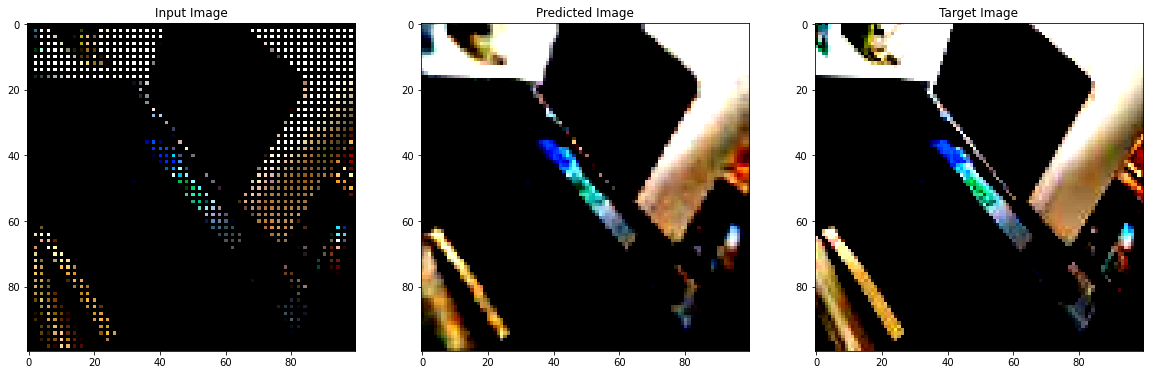

In [85]:
idx = 99
data_dict = val_dict
loss_idcs = middle_loss_indices

input_image = np.moveaxis(data_dict["input_images"][loss_idcs][idx], 0, -1)
pred_image = np.moveaxis(data_dict["pred_images"][loss_idcs][idx], 0, -1)
target_image = np.moveaxis(data_dict["target_images"][loss_idcs][idx], 0, -1)

fig, axs = plt.subplots(1,3, figsize=(20,20))

axs[0].imshow(input_image)
axs[0].set_title("Input Image")

axs[1].imshow(pred_image)
axs[1].set_title("Predicted Image")

axs[2].imshow(target_image)
axs[2].set_title("Target Image")